### Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("funnel_events_sample.csv")

In [3]:
df.shape

(542, 3)

In [4]:
df.head()

,user_id,step,timestamp
0,U176,details_filled,2026-07-20 04:23:00
1,U102,signup_started,2026-07-20 03:56:00
2,U138,visited_site,2026-07-20 03:59:00
3,U007,signup_started,2026-07-20 04:14:00
4,U143,signup_started,2026-07-20 03:45:00


### Handling Data Quality

In [5]:
df = df.drop_duplicates(subset=["user_id", "step"])

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [7]:
df.head()

,user_id,step,timestamp
0,U176,details_filled,2026-07-20 04:23:00
1,U102,signup_started,2026-07-20 03:56:00
2,U138,visited_site,2026-07-20 03:59:00
3,U007,signup_started,2026-07-20 04:14:00
4,U143,signup_started,2026-07-20 03:45:00


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    542 non-null    object        
 1   step       542 non-null    object        
 2   timestamp  542 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 12.8+ KB


In [9]:
df.isnull().sum()

user_id      0
step         0
timestamp    0
dtype: int64

In [10]:
df.duplicated().sum()

0

### Understanding Funnel Data(Step Ordering Awareness)

In [11]:
steps = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

### Aggregate unique users

In [12]:
stage_counts = (
    df.groupby("step")["user_id"]
      .nunique()
      .reindex(steps)
)

print(stage_counts)

step
visited_site          200
signup_started        150
details_filled         96
email_verified         52
purchase_completed     44
Name: user_id, dtype: int64


### Observations
1. Number of users visited_site are 200
2. Number of users signup_started are 150
3. Number of users details_filled are 96
4. Number of users email_verified are 52
5. Number of users email_verified are 44

### Create the analysis table

In [13]:
result = pd.DataFrame({
    "Stage": steps,
    "Users": stage_counts.values
})

In [14]:
result

,Stage,Users
0,visited_site,200
1,signup_started,150
2,details_filled,96
3,email_verified,52
4,purchase_completed,44


### Calculate Conversion Rates

In [15]:
result["Conversion %"] = (
    result["Users"] /
    result["Users"].shift(1) * 100
)

result.loc[0, "Conversion %"] = 100

### Calculate Drop-Off

In [16]:
result["Drop-off"] = (
    result["Users"].shift(1) -
    result["Users"]
)

result.loc[0, "Drop-off"] = 0

### Biggest drop-off 

In [17]:
largest = result.iloc[result["Drop-off"].idxmax()]

print("Biggest Drop-off")
print("----------------")
print(f"Stage: {largest['Stage']}")
print(f"Users Lost: {int(largest['Drop-off'])}")

Biggest Drop-off
----------------
Stage: details_filled
Users Lost: 54


### Funnel visualization

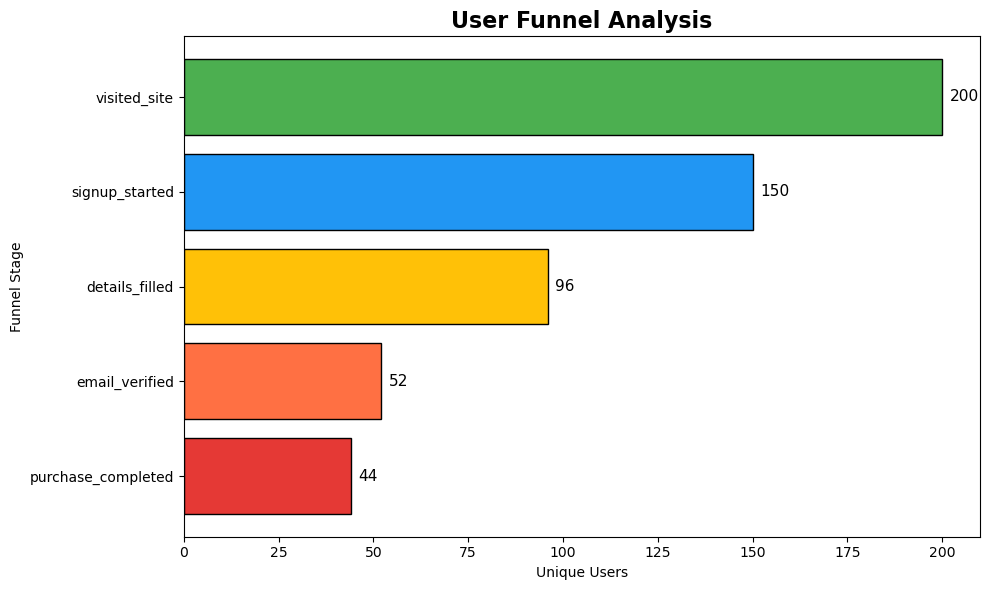

In [22]:
colors = [
    "#4CAF50",   # Green
    "#2196F3",   # Blue
    "#FFC107",   # Amber
    "#FF7043",   # Orange
    "#E53935"    # Red
]
plt.figure(figsize=(10, 6))

bars = plt.barh(
    result["Stage"],
    result["Users"],
    color=colors,
    edgecolor="black"
)
### Add user count labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center",
        fontsize=11
    )

plt.title("User Funnel Analysis", fontsize=16, weight="bold")
plt.xlabel("Unique Users")
plt.ylabel("Funnel Stage")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Time-to-convert
Calculate the average time users take between two consecutive stages, in addition to the conversion rate.

In [23]:
pivot = df.pivot_table(
    index="user_id",
    columns="step",
    values="timestamp",
    aggfunc="min"
)

In [24]:
(
    pivot["signup_started"] -
    pivot["visited_site"]
).mean()

Timedelta('0 days 00:12:17.200000')

### Segment comparison
If you assign users a rough segment (e.g., by user_id pattern), compare conversion rates across segments.

In [25]:
df["segment"] = df["user_id"].str[-1]

segment_counts = (
    df.groupby(["segment", "step"])["user_id"]
      .nunique()
      .unstack()
)

In [26]:
segment_counts

step,details_filled,email_verified,purchase_completed,signup_started,visited_site
segment,,,,,
0,9,5,5,15,20
1,10,5,5,15,20
2,10,5,5,15,20
3,10,5,4,15,20
4,10,5,4,15,20
5,10,5,4,15,20
6,10,5,4,15,20
7,9,6,4,15,20
8,9,6,4,15,20


### Recommendation note
The largest drop-off occurs between Signup Started and Details Filled, indicating that users abandon the registration form. Reducing the number of required fields, enabling autofill, or breaking the form into smaller steps could improve completion rates. This stage should be prioritized for UX improvements and A/B testing.